In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
X = df["YearsExperience"].values
Y = df["Salary"].values

In [7]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [8]:
Y

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

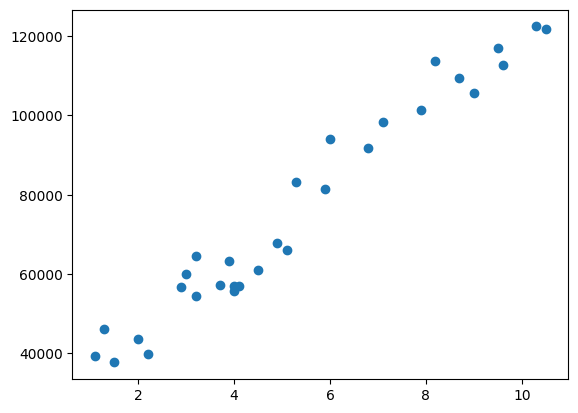

In [9]:
plt.scatter(X,Y)
plt.show()

In [10]:
X = np.array(X)
Y = np.array(Y)

In [11]:
def mean(X):
  return np.sum(X)/len(X)

In [12]:
def variance(X):
  mean_value = mean(X)
  variance_value = np.sum((X-mean_value)**2)/len(X)
  return variance_value

In [13]:
def norm(X):
  mean_value = mean(X)
  variance_value = variance(X)
  norm_value =(X-mean_value)/np.sqrt(variance_value)
  return norm_value

In [15]:
X_norm = norm(X)

In [22]:
X

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

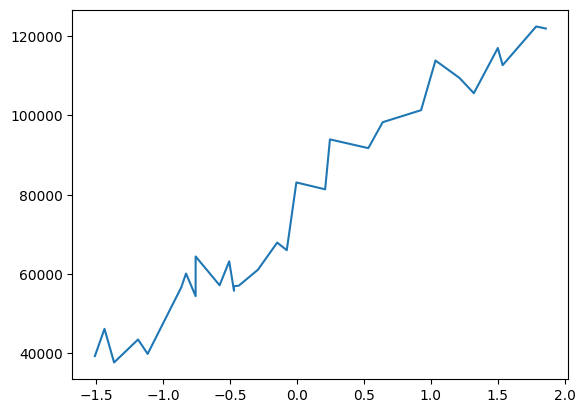

In [17]:
plt.plot(X_norm,Y)

In [19]:
import random

In [48]:
class SimpleLR:
  def __init__(self,lr=0.1,max_itr=200,threshold=1e-6):
    self.lr = lr
    self.max_itr = max_itr
    self.threshold = threshold
    self.weight = random.uniform(-1,1)
    self.bais = random.uniform(-1,1)

  def predict(self,X):
    return self.weight*X+self.bais

  def fit(self,X,Y):
    n = len(X)
    loss_history = []
    y_pred = self.predict(X)
    error = y_pred-Y
    prev_loss = (1/(2*n))*np.sum(error**2)
    loss_history.append(prev_loss)

    for i in range(self.max_itr):
      dw = 1/n*np.sum(error*X)
      db = 1/n*np.sum(error)
      self.weight = self.weight-self.lr*dw
      self.bais = self.bais-self.lr*db
      y_pred = self.predict(X)
      error = y_pred-Y
      curr_loss = (1/(2*n))*np.sum(error**2)
      if abs(prev_loss-curr_loss)<self.threshold:
        break
      prev_loss = curr_loss
      loss_history.append(curr_loss)
    return loss_history

  def plot(self,X,Y):
    plt.plot(X,Y)
    plt.plot(X,self.predict(X))
    plt.show()


In [49]:
model = SimpleLR()

In [50]:
loss_history = model.fit(X_norm,Y)

In [40]:
loss_history

[np.float64(3251400673.693696),
 np.float64(2636605286.1055107),
 np.float64(2138621022.1590805),
 np.float64(1735253768.3624718),
 np.float64(1408526292.787219),
 np.float64(1143877037.5712638),
 np.float64(929511140.8463407),
 np.float64(755874764.4991528),
 np.float64(615229299.6579304),
 np.float64(501306473.13654035),
 np.float64(409028983.6542142),
 np.float64(334284217.1735303),
 np.float64(273740956.32417625),
 np.float64(224700915.0361995),
 np.float64(184978481.59293827),
 np.float64(152803310.50389674),
 np.float64(126741421.92177305),
 np.float64(105631292.17025289),
 np.float64(88532087.07152146),
 np.float64(74681730.94154914),
 np.float64(63462942.4762715),
 np.float64(54375723.81939662),
 np.float64(47015076.707327925),
 np.float64(41052952.54655228),
 np.float64(36223631.976324),
 np.float64(32311882.314439144),
 np.float64(29143365.08831243),
 np.float64(26576866.13514977),
 np.float64(24498001.983087998),
 np.float64(22814122.01991797),
 np.float64(21450179.249750264

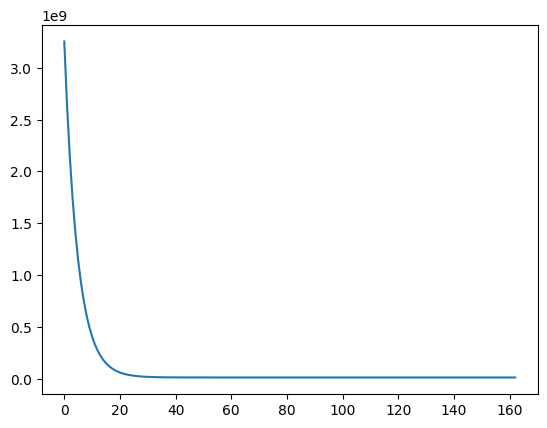

In [46]:
plt.plot(loss_history)

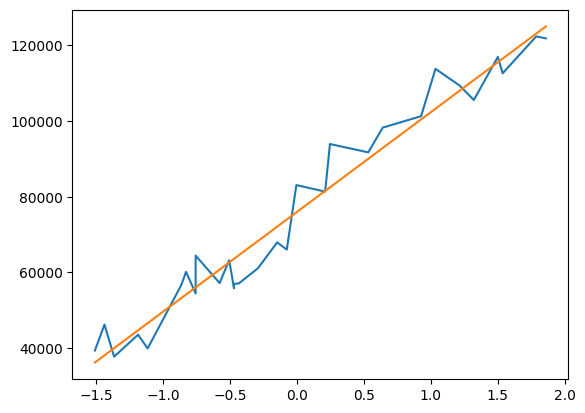

In [51]:
model.plot(X_norm,Y)